# CO2 Emissions by Vehicle — Multivariate Regression Analysis

**Mission:** Help consumers and manufacturers reduce environmental impact by predicting vehicle CO2 emissions based on engine specifications and fuel type.

**Dataset:** CO2 Emissions Canada — Government of Canada / Kaggle  
**Source:** https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles  
**Records:** 7,385 rows | **Features:** 11 columns + 1 target  

**Target:** `CO2 Emissions(g/km)` — grams of CO2 emitted per kilometre driven

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All imports successful.')

All imports successful.


## 2. Load Dataset

In [2]:
df = pd.read_csv('CO2_Emissions_Canada.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (7385, 12)

Columns: ['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
print(df.info())
print('\n--- Descriptive Statistics ---')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


## 3. Exploratory Data Analysis & Visualizations

### 3.1 Visualization 1 — Correlation Heatmap

**Interpretation:** Shows pairwise Pearson correlations between numeric features and the target. This guides which columns to retain and which are redundant.

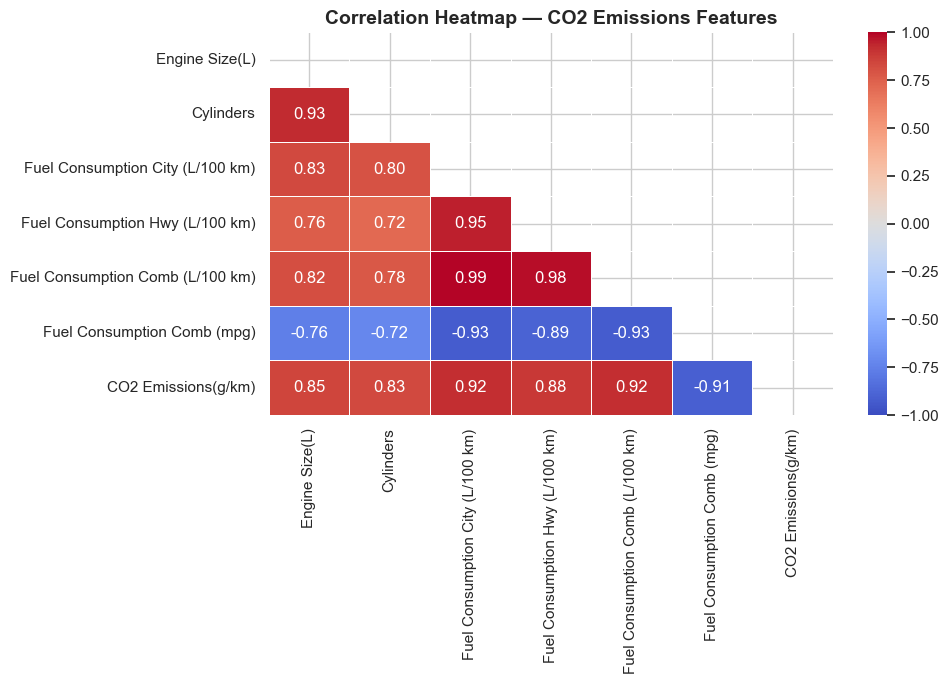


--- Correlation with CO2 Emissions ---
CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


In [4]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Correlation Heatmap — CO2 Emissions Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Correlation with CO2 Emissions ---')
print(corr_matrix['CO2 Emissions(g/km)'].sort_values(ascending=False))

**Interpretation:**
- `Fuel Consumption Comb (L/100 km)` has the highest correlation with CO2 (r = 0.92) — retained as the single fuel consumption metric.
- `Fuel Consumption City` and `Fuel Consumption Hwy` are highly correlated with `Comb` (r > 0.97) — **dropped as redundant**.
- `Fuel Consumption Comb (mpg)` is a unit conversion of `Comb (L/100 km)` (r = -0.91) — **dropped**.
- `Engine Size` and `Cylinders` both correlate strongly with CO2 (r = 0.85) — **retained**.

### 3.2 Visualization 2 — CO2 Distributions & Key Relationships

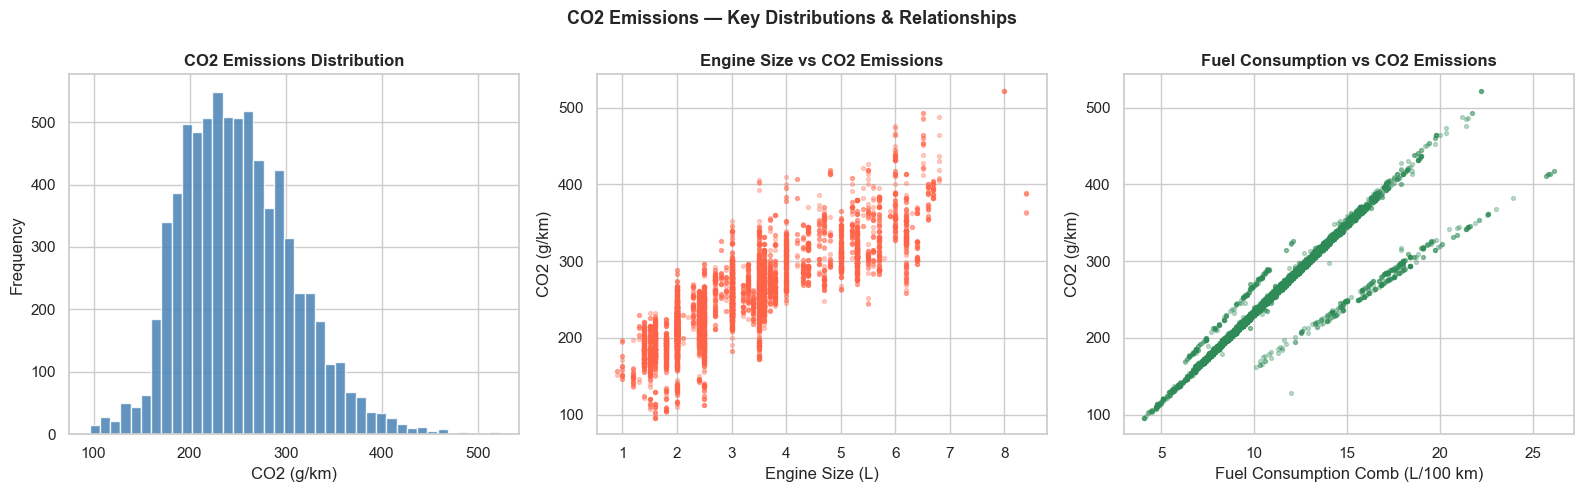

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['CO2 Emissions(g/km)'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('CO2 Emissions Distribution', fontweight='bold')
axes[0].set_xlabel('CO2 (g/km)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['Engine Size(L)'], df['CO2 Emissions(g/km)'], alpha=0.3, s=8, color='tomato')
axes[1].set_title('Engine Size vs CO2 Emissions', fontweight='bold')
axes[1].set_xlabel('Engine Size (L)')
axes[1].set_ylabel('CO2 (g/km)')

axes[2].scatter(df['Fuel Consumption Comb (L/100 km)'], df['CO2 Emissions(g/km)'], alpha=0.3, s=8, color='seagreen')
axes[2].set_title('Fuel Consumption vs CO2 Emissions', fontweight='bold')
axes[2].set_xlabel('Fuel Consumption Comb (L/100 km)')
axes[2].set_ylabel('CO2 (g/km)')

plt.suptitle('CO2 Emissions — Key Distributions & Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** CO2 emissions follow a roughly normal distribution centred around 250 g/km. Both `Engine Size` and `Fuel Consumption Comb` show clear positive linear relationships with CO2, confirming their predictive power.

### 3.3 Visualization 3 — CO2 Emissions by Fuel Type

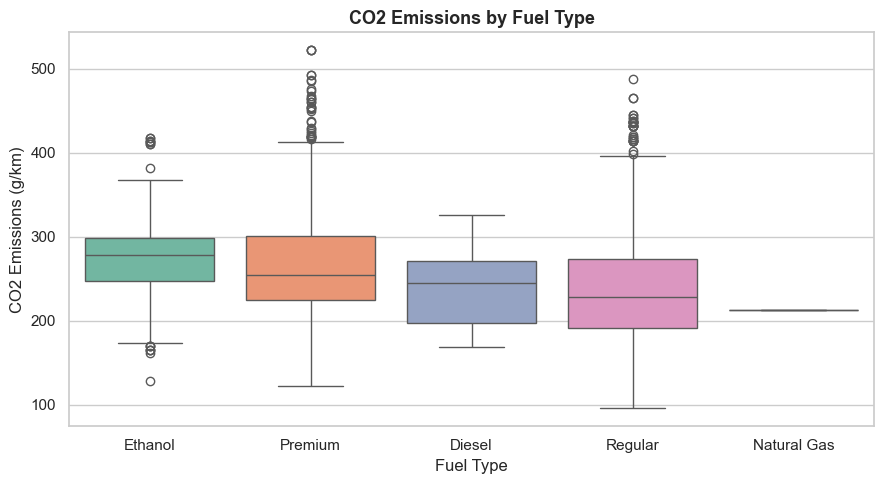

In [6]:
fuel_labels = {'X': 'Regular', 'Z': 'Premium', 'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas'}
df['Fuel Label'] = df['Fuel Type'].map(fuel_labels)

plt.figure(figsize=(9, 5))
order = df.groupby('Fuel Label')['CO2 Emissions(g/km)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Fuel Label', y='CO2 Emissions(g/km)', order=order, palette='Set2')
plt.title('CO2 Emissions by Fuel Type', fontsize=13, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

df.drop(columns=['Fuel Label'], inplace=True)

**Interpretation:** Natural Gas and Ethanol vehicles emit significantly less CO2 than petrol vehicles. Diesel sits in the middle. This confirms `Fuel Type` is a meaningful categorical predictor.

## 4. Feature Engineering & Data Cleaning

In [7]:
print('--- Null Values ---')
print(df.isnull().sum())

n_dups = df.duplicated().sum()
print(f'\nDuplicate rows: {n_dups}')
if n_dups > 0:
    df = df.drop_duplicates()
    print(f'Dropped {n_dups} duplicates. New shape: {df.shape}')

--- Null Values ---
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Duplicate rows: 1103
Dropped 1103 duplicates. New shape: (6282, 12)


In [8]:
df.drop(columns=['Make', 'Model'], inplace=True)

df.drop(columns=[
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (mpg)'
], inplace=True)

print('Remaining columns:', df.columns.tolist())
print('Shape after drops:', df.shape)

Remaining columns: ['Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']
Shape after drops: (6282, 7)


In [9]:
df['Transmission Type'] = df['Transmission'].apply(lambda x: re.sub(r'\d+', '', x))
df.drop(columns=['Transmission'], inplace=True)

print('Transmission types:', df['Transmission Type'].unique())
print('Value counts:')
print(df['Transmission Type'].value_counts())

Transmission types: <StringArray>
['AS', 'M', 'AV', 'AM', 'A']
Length: 5, dtype: str
Value counts:
Transmission Type
AS    2722
A     1536
M     1019
AM     540
AV     465
Name: count, dtype: int64


In [10]:
categorical_cols = ['Vehicle Class', 'Fuel Type', 'Transmission Type']
label_encoders   = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes -> {list(le.classes_)}')

Vehicle Class: 16 classes -> ['COMPACT', 'FULL-SIZE', 'MID-SIZE', 'MINICOMPACT', 'MINIVAN', 'PICKUP TRUCK - SMALL', 'PICKUP TRUCK - STANDARD', 'SPECIAL PURPOSE VEHICLE', 'STATION WAGON - MID-SIZE', 'STATION WAGON - SMALL', 'SUBCOMPACT', 'SUV - SMALL', 'SUV - STANDARD', 'TWO-SEATER', 'VAN - CARGO', 'VAN - PASSENGER']
Fuel Type: 5 classes -> ['D', 'E', 'N', 'X', 'Z']
Transmission Type: 5 classes -> ['A', 'AM', 'AS', 'AV', 'M']


In [11]:
FEATURES = [
    'Vehicle Class',
    'Engine Size(L)',
    'Cylinders',
    'Transmission Type',
    'Fuel Type',
    'Fuel Consumption Comb (L/100 km)'
]
TARGET = 'CO2 Emissions(g/km)'

X = df[FEATURES].values
y = df[TARGET].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (6282, 6)
y shape: (6282,)


## 5. Preprocessing — Train/Test Split & Standardization

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nFeature means after scaling (should be ~0):', X_train_scaled.mean(axis=0).round(4))
print('Feature stds after scaling  (should be ~1):', X_train_scaled.std(axis=0).round(4))

Train size: 5025 | Test size: 1257

Feature means after scaling (should be ~0): [-0.  0. -0. -0.  0. -0.]
Feature stds after scaling  (should be ~1): [1. 1. 1. 1. 1. 1.]


## 6. Linear Regression with Gradient Descent

We implement **batch gradient descent** from scratch so we can capture a full loss curve. The update rule at each epoch is:

$$w := w - \alpha_t \cdot \frac{2}{n} X^T(Xw - y), \quad b := b - \alpha_t \cdot \frac{2}{n}\sum(Xw - y)$$

A **decaying learning rate** $\alpha_t = \frac{\alpha_0}{1 + \text{decay} \times t}$ is used so that updates shrink as the model converges, preventing the test loss from creeping upward in later epochs.

After training, the learned weights are transferred into a scikit-learn `SGDRegressor` so the model integrates with the sklearn pipeline.

In [13]:
N_EPOCHS = 200
LR0      = 0.05
DECAY    = 0.02
n_samples = X_train_scaled.shape[0]

np.random.seed(0)
w = np.random.randn(X_train_scaled.shape[1]) * 10
b = np.random.randn() * 10

train_losses = []
test_losses  = []

for epoch in range(N_EPOCHS):
    lr        = LR0 / (1 + DECAY * epoch)
    y_pred_tr = X_train_scaled @ w + b
    error     = y_pred_tr - y_train
    w -= lr * (2 / n_samples) * (X_train_scaled.T @ error)
    b -= lr * (2 / n_samples) * error.sum()
    train_losses.append(mean_squared_error(y_train, X_train_scaled @ w + b))
    test_losses.append(mean_squared_error(y_test,   X_test_scaled  @ w + b))

lr_train_mse = train_losses[-1]
lr_test_mse  = test_losses[-1]

sgd_model = SGDRegressor()
sgd_model.fit(X_train_scaled, y_train)
sgd_model.coef_      = w
sgd_model.intercept_ = np.array([b])

print(f'Linear Regression (GD) -- Train MSE: {lr_train_mse:.4f} | Test MSE: {lr_test_mse:.4f}')
print(f'Linear Regression (GD) -- Train RMSE: {np.sqrt(lr_train_mse):.4f} | Test RMSE: {np.sqrt(lr_test_mse):.4f}')

Linear Regression (GD) -- Train MSE: 350.4006 | Test MSE: 367.3428
Linear Regression (GD) -- Train RMSE: 18.7190 | Test RMSE: 19.1662


### 6.1 Loss Curve — Linear Regression (Gradient Descent)

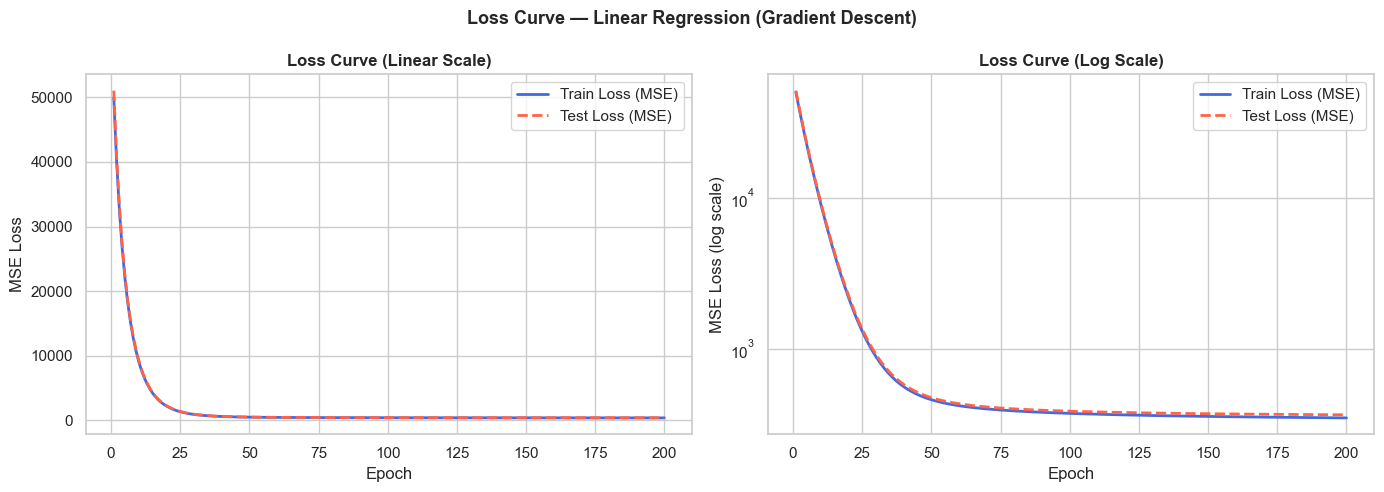

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, train_losses, label='Train Loss (MSE)', color='royalblue', linewidth=2)
axes[0].plot(epochs, test_losses,  label='Test Loss (MSE)',  color='tomato',    linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Loss Curve (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)

axes[1].plot(epochs, train_losses, label='Train Loss (MSE)', color='royalblue', linewidth=2)
axes[1].plot(epochs, test_losses,  label='Test Loss (MSE)',  color='tomato',    linewidth=2, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss (log scale)', fontsize=12)
axes[1].set_title('Loss Curve (Log Scale)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Loss Curve — Linear Regression (Gradient Descent)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Decision Tree Regressor

Decision Tree -- Train MSE: 10.5356 | Test MSE: 29.7917
Decision Tree -- Train RMSE: 3.2459 | Test RMSE: 5.4582


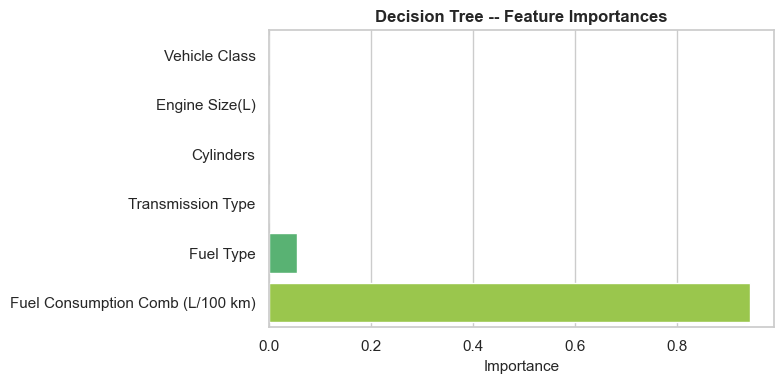

In [15]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_train_mse = mean_squared_error(y_train, dt_model.predict(X_train_scaled))
dt_test_mse  = mean_squared_error(y_test,  dt_model.predict(X_test_scaled))

print(f'Decision Tree -- Train MSE: {dt_train_mse:.4f} | Test MSE: {dt_test_mse:.4f}')
print(f'Decision Tree -- Train RMSE: {np.sqrt(dt_train_mse):.4f} | Test RMSE: {np.sqrt(dt_test_mse):.4f}')

plt.figure(figsize=(8, 4))
sns.barplot(x=dt_model.feature_importances_, y=FEATURES, palette='viridis')
plt.xlabel('Importance', fontsize=11)
plt.title('Decision Tree -- Feature Importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Random Forest Regressor

Random Forest -- Train MSE: 15.9941 | Test MSE: 35.5763
Random Forest -- Train RMSE: 3.9993 | Test RMSE: 5.9646


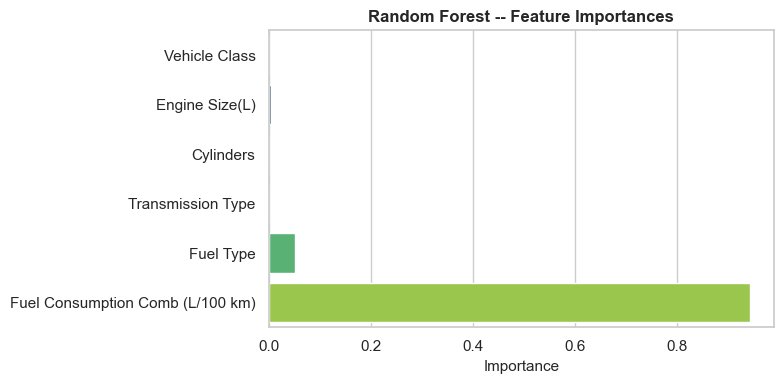

In [16]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_train_mse = mean_squared_error(y_train, rf_model.predict(X_train_scaled))
rf_test_mse  = mean_squared_error(y_test,  rf_model.predict(X_test_scaled))

print(f'Random Forest -- Train MSE: {rf_train_mse:.4f} | Test MSE: {rf_test_mse:.4f}')
print(f'Random Forest -- Train RMSE: {np.sqrt(rf_train_mse):.4f} | Test RMSE: {np.sqrt(rf_test_mse):.4f}')

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_model.feature_importances_, y=FEATURES, palette='viridis')
plt.xlabel('Importance', fontsize=11)
plt.title('Random Forest -- Feature Importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Linear Regression (GD)', 'Decision Tree', 'Random Forest'],
    'Train MSE':  [lr_train_mse,  dt_train_mse,  rf_train_mse],
    'Test MSE':   [lr_test_mse,   dt_test_mse,   rf_test_mse],
    'Train RMSE': [np.sqrt(lr_train_mse), np.sqrt(dt_train_mse), np.sqrt(rf_train_mse)],
    'Test RMSE':  [np.sqrt(lr_test_mse),  np.sqrt(dt_test_mse),  np.sqrt(rf_test_mse)],
    'Test R2':    [
        r2_score(y_test, sgd_model.predict(X_test_scaled)),
        r2_score(y_test, dt_model.predict(X_test_scaled)),
        r2_score(y_test, rf_model.predict(X_test_scaled)),
    ]
})

results = results.sort_values('Test MSE').reset_index(drop=True)
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f'\n>>> Best model (lowest Test MSE): {best_model_name}')

                 Model  Train MSE   Test MSE  Train RMSE  Test RMSE  Test R2
         Decision Tree  10.535564  29.791750    3.245853   5.458182 0.991745
         Random Forest  15.994104  35.576326    3.999263   5.964589 0.990142
Linear Regression (GD) 350.400614 367.342849   18.718991  19.166190 0.898207

>>> Best model (lowest Test MSE): Decision Tree


## 10. Scatter Plot: Before and After Linear Regression Fit

Using `Fuel Consumption Comb` (strongest single predictor) as the x-axis.

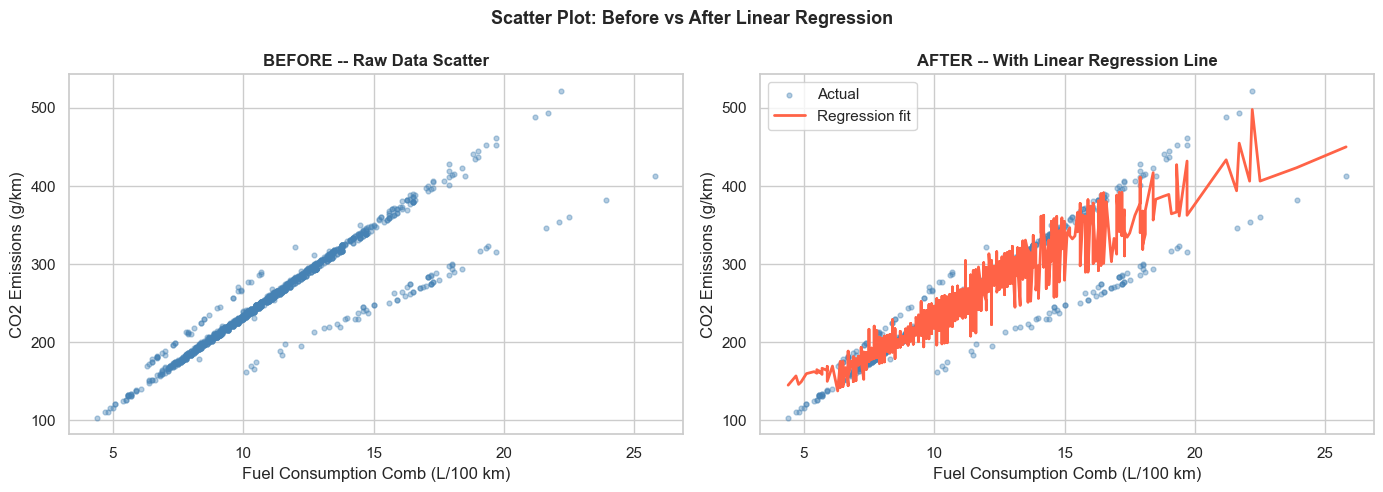

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fuel_idx = FEATURES.index('Fuel Consumption Comb (L/100 km)')
x_raw    = X_test[:, fuel_idx]

axes[0].scatter(x_raw, y_test, alpha=0.4, s=12, color='steelblue')
axes[0].set_title('BEFORE -- Raw Data Scatter', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fuel Consumption Comb (L/100 km)')
axes[0].set_ylabel('CO2 Emissions (g/km)')

y_pred_lr = sgd_model.predict(X_test_scaled)
sort_idx  = np.argsort(x_raw)

axes[1].scatter(x_raw, y_test, alpha=0.4, s=12, color='steelblue', label='Actual')
axes[1].plot(x_raw[sort_idx], y_pred_lr[sort_idx], color='tomato', linewidth=2, label='Regression fit')
axes[1].set_title('AFTER -- With Linear Regression Line', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fuel Consumption Comb (L/100 km)')
axes[1].set_ylabel('CO2 Emissions (g/km)')
axes[1].legend()

plt.suptitle('Scatter Plot: Before vs After Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Best Model & Scaler

In [19]:
model_map = {
    'Linear Regression (GD)': sgd_model,
    'Decision Tree':          dt_model,
    'Random Forest':          rf_model,
}

best_model = model_map[best_model_name]

api_dir = os.path.join('..', 'API')
os.makedirs(api_dir, exist_ok=True)

joblib.dump(best_model,     os.path.join(api_dir, 'best_model.pkl'))
joblib.dump(scaler,         os.path.join(api_dir, 'scaler.pkl'))
joblib.dump(label_encoders, os.path.join(api_dir, 'label_encoders.pkl'))

print(f'Best model saved: {os.path.join(api_dir, "best_model.pkl")}')
print(f'Scaler    saved: {os.path.join(api_dir, "scaler.pkl")}')
print(f'Encoders  saved: {os.path.join(api_dir, "label_encoders.pkl")}')

Best model saved: ..\API\best_model.pkl
Scaler    saved: ..\API\scaler.pkl
Encoders  saved: ..\API\label_encoders.pkl


## 12. Prediction on One Data Point (from Test Set)

In [20]:
sample_scaled = X_test_scaled[0].reshape(1, -1)

prediction = best_model.predict(sample_scaled)[0]
actual     = y_test[0]

print('--- Single-Sample Prediction ---')
for feature_name, value in zip(FEATURES, X_test[0]):
    print(f'  {feature_name}: {value}')

print(f'\n  Predicted CO2 Emissions : {prediction:.2f} g/km')
print(f'  Actual    CO2 Emissions : {actual:.2f} g/km')
print(f'  Error                   : {abs(prediction - actual):.2f} g/km')

--- Single-Sample Prediction ---
  Vehicle Class: 12.0
  Engine Size(L): 3.0
  Cylinders: 6.0
  Transmission Type: 2.0
  Fuel Type: 0.0
  Fuel Consumption Comb (L/100 km): 12.0

  Predicted CO2 Emissions : 295.50 g/km
  Actual    CO2 Emissions : 322.00 g/km
  Error                   : 26.50 g/km
